In [1]:
import matplotlib.pyplot as plt
import numpy as np
import sys
sys.path.append('../')
sys.path.append('../../Share/')
import baseline, config
import self_supervised_v1

import warnings
warnings.filterwarnings('ignore')

def plot_result(result):
    plt.figure(figsize=(10, 5))
    plt.plot(result.history['accuracy'], label='accuracy', marker='o')
    plt.plot(result.history['val_accuracy'], label='val_accuracy', marker='o')
    plt.title('Pre-training Stage')
    plt.xlabel('Epochs')
    plt.ylabel('Accuracy')
    plt.grid(True, linestyle='--', alpha=0.6)
    plt.legend(loc='lower right')
    plt.tight_layout()
    plt.show()


from collections import Counter

def balance_data(X, y):
    # Count samples per class
    class_counts = Counter(y)
    min_count = min(class_counts.values())  # target: balance all to minority count

    indices_list = []

    for label in sorted(class_counts.keys()):
        label_indices = np.where(y == label)[0]
        selected_indices = np.random.choice(label_indices, size=min_count, replace=False)
        indices_list.extend(selected_indices)

    # Shuffle all selected indices
    balanced_indices = np.random.permutation(indices_list)

    # Subset the data
    X_balanced = X[balanced_indices]
    y_balanced = y[balanced_indices]

    return X_balanced, y_balanced



from sklearn.metrics import confusion_matrix
import seaborn as sns
from tensorflow import keras


def heatmap_confusion_matrix(X_test, y_test, model):
    # Predict class labels on the test set
    y_pred_probs = model.predict(X_test, verbose=0)
    y_pred = np.argmax(y_pred_probs, axis=1)  # convert softmax probs to predicted class
    y_true = y_test
    cm = confusion_matrix(y_true, y_pred)

    plt.figure(figsize=(8, 6))
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=range(np.max(y_test)+1), yticklabels=range(np.max(y_test)+1))
    plt.xlabel('Predicted Label')
    plt.ylabel('True Label')
    plt.title('Confusion Matrix')
    plt.show()

    return cm



SUBJECT = "Hunmin"
trainer = baseline.ModelTrainer(config, subject=SUBJECT)

Dataset 1/66 - Session Exp_2025-05-27/E8331D05289A/
Dataset 2/66 - Session Exp_2025-06-18/E9AD0E7DCC2B/
Dataset 3/66 - Session Exp_2025-06-20-v1/E9AD0E7DCC2B/
Dataset 4/66 - Session Exp_2025-06-20-v2/E9AD0E7DCC2B/
Dataset 5/66 - Session Exp_2025-06-20-v3/E9AD0E7DCC2B/
Dataset 6/66 - Session Exp_2025-06-20-v4/E9AD0E7DCC2B/
Dataset 7/66 - Session Exp_2025-06-20-v5/E9AD0E7DCC2B/
Dataset 8/66 - Session Exp_2025-06-20-v6/E9AD0E7DCC2B/
Dataset 9/66 - Session Exp_2025-06-20-v7/E9AD0E7DCC2B/
Dataset 10/66 - Session Exp_2025-06-20-v8/E9AD0E7DCC2B/
(31050, 4, 14, 1) (31050,) (7692, 4, 14, 1) (7692,)


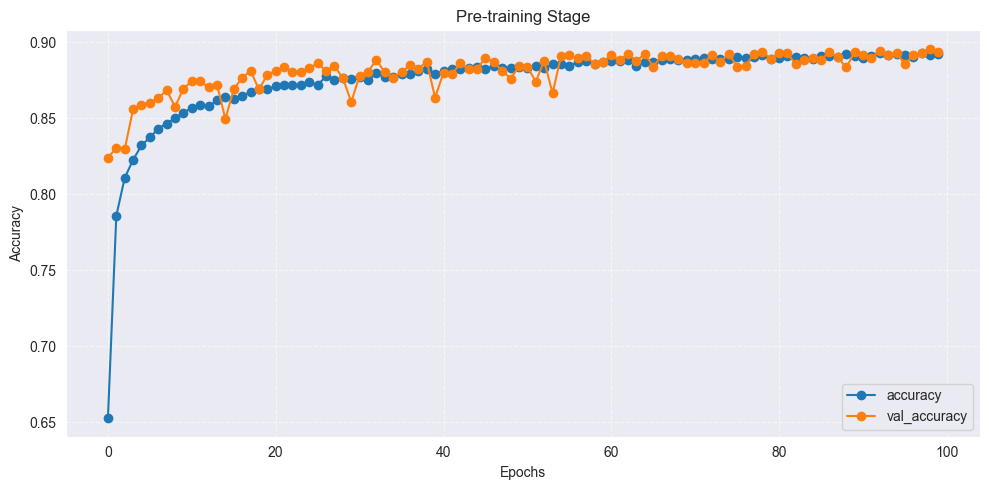

In [2]:
Threshold_K = 10  # 초기 학습 데이터
X_init, y_init, X_init_test, y_init_test = trainer.return_until_K_data(K=Threshold_K, train_ratio=0.8)
X_init, y_init = balance_data(X_init, y_init)
X_init_test, y_init_test = balance_data(X_init_test, y_init_test)

print(X_init.shape, y_init.shape, X_init_test.shape, y_init_test.shape)

model_K4 = self_supervised_v1.build_model()  # 모델 생성 및 초기 학습
result = model_K4.fit(X_init, y_init, validation_data=(X_init_test, y_init_test), epochs=100, batch_size=128, verbose=0)
plot_result(result)

In [3]:
model = model_K4
Threshold_K=10

In [5]:
final_session = len(config.Info_sub_H)
# Accuracy 저장 리스트
Same_Session_Test_Acc, Next_Session_Test_Acc = [], []

def evaluate_model(model, data, labels):
    return model.evaluate(data, labels, verbose=0)[1]

# 온라인 학습 루프
for session in range(Threshold_K, final_session-1):
    # 현재 세션 데이터
    X_train, _, X_test, y_test = trainer.return_K_th_data_only(K=session, train_ratio=0.8)
    #balance_data(X_test, y_test)
    # Pseudo-label 생성 및 온라인 업데이트
    pseudo_labels = self_supervised_v1.generate_pseudo_label(model, X_train)
    #X_train, pseudo_labels = balance_data(X_train, pseudo_labels)
    model = self_supervised_v1.online_update(model, X_train, pseudo_labels)

    # 같은 세션 테스트
    Same_Session_Test_Acc.append(evaluate_model(model, X_test, y_test))

    # 다음 세션 테스트
    next_X, next_y, _, _ = trainer.return_K_th_data_only(K=session + 1, train_ratio=1)
    Next_Session_Test_Acc.append(evaluate_model(model, next_X, next_y))

Returning K-th session data: Exp_2025-06-23-v1/E9AD0E7DCC2B/
Returning K-th session data: Exp_2025-06-23-v2/E9AD0E7DCC2B/
Returning K-th session data: Exp_2025-06-23-v2/E9AD0E7DCC2B/
Returning K-th session data: Exp_2025-06-23-v3/E9AD0E7DCC2B/
Returning K-th session data: Exp_2025-06-23-v3/E9AD0E7DCC2B/
Returning K-th session data: Exp_2025-06-23-v4/E9AD0E7DCC2B/
Returning K-th session data: Exp_2025-06-23-v4/E9AD0E7DCC2B/
Returning K-th session data: Exp_2025-06-24-v1/E9AD0E7DCC2B/
Returning K-th session data: Exp_2025-06-24-v1/E9AD0E7DCC2B/
Returning K-th session data: Exp_2025-06-24-v2/E9AD0E7DCC2B/
Returning K-th session data: Exp_2025-06-24-v2/E9AD0E7DCC2B/
Returning K-th session data: Exp_2025-06-24-v3/E9AD0E7DCC2B/
Returning K-th session data: Exp_2025-06-24-v3/E9AD0E7DCC2B/
Returning K-th session data: Exp_2025-06-24-v4/E9AD0E7DCC2B/
Returning K-th session data: Exp_2025-06-24-v4/E9AD0E7DCC2B/
Returning K-th session data: Exp_2025-06-26-v1/E9AD0E7DCC2B/
Returning K-th session d

0.9072033166885376


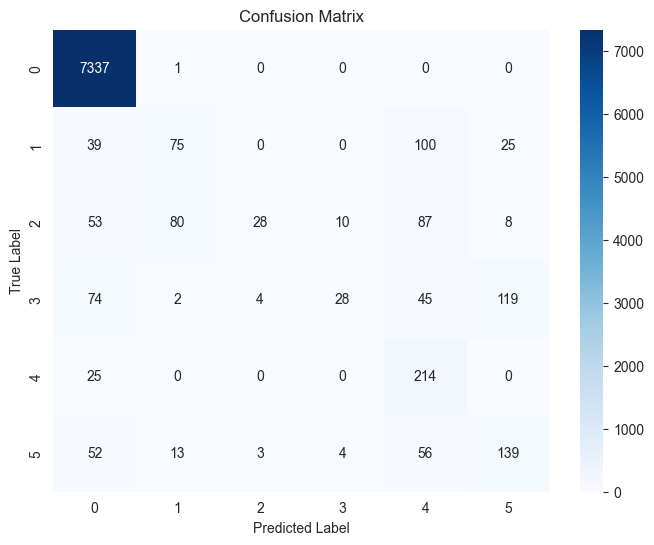

In [6]:
acc = model.evaluate(next_X, next_y, verbose=0)[1]
print(acc)

cm = heatmap_confusion_matrix(next_X, next_y, model)

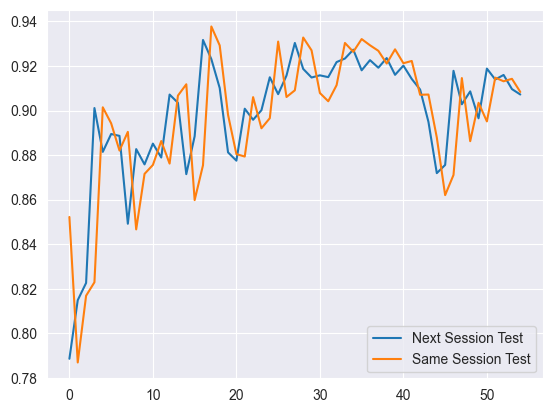

In [7]:
plt.plot(Next_Session_Test_Acc, label='Next Session Test')
plt.plot(Same_Session_Test_Acc, label='Same Session Test')
plt.legend()
plt.show()